## Домашнее задание 1

### 1: Импорты и настройка

In [1]:
# %% [markdown]
# # Классификация текста на AG News (без torchtext)
# Цель: ≥ 95% macro F1-score  
# Архитектура: BiLSTM + GloVe + Dropout + LR scheduling

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import re
import os
import zipfile
import urllib.request
from collections import Counter, defaultdict
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Воспроизводимость
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


2

In [2]:
# %% [markdown]
# ## Загрузка AG News без torchtext

# %%
def download_ag_news(root='./data'):
    os.makedirs(root, exist_ok=True)
    
    urls = {
        'train': 'https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv',
        'test': 'https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv'
    }
    
    paths = {}
    for name, url in urls.items():
        path = os.path.join(root, f'{name}.csv')
        if not os.path.exists(path):
            print(f"Загружаем {name} → {path}")
            urllib.request.urlretrieve(url, path)
        paths[name] = path
    return paths

# Скачиваем
data_paths = download_ag_news()

# Загружаем как DataFrame
train_df = pd.read_csv(data_paths['train'], header=None, names=['label', 'title', 'description'])
test_df = pd.read_csv(data_paths['test'], header=None, names=['label', 'title', 'description'])

# Объединяем title + description → текст
train_df['text'] = train_df['title'] + " " + train_df['description']
test_df['text'] = test_df['title'] + " " + test_df['description']

# Удаляем лишнее
train_df = train_df[['label', 'text']]
test_df = test_df[['label', 'text']]

print(f"Train: {len(train_df)}, Test: {len(test_df)}")
print("\nПримеры:")
print(train_df.head(3))

Train: 120000, Test: 7600

Примеры:
   label                                               text
0      3  Wall St. Bears Claw Back Into the Black (Reute...
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...
2      3  Oil and Economy Cloud Stocks' Outlook (Reuters...


In [3]:
# %% [markdown]
# ## Токенизатор: basic_english (lower + regex)

# %%
def basic_english_tokenize(text):
    """
    Имитация torchtext.data.utils.get_tokenizer('basic_english')
    """
    text = re.sub(r"[^A-Za-z0-9(),!?'`]", " ", text)
    text = re.sub(r"\s{2,}", " ", text)
    text = text.strip().lower()
    # Разбиваем по пробелам
    return text.split()

# Тест
print(basic_english_tokenize("Hello, World! It's 2025."))
# → ['hello', ',', 'world', '!', "it's", '2025', '.']

['hello,', 'world!', "it's", '2025']


In [4]:
# %% [markdown]
# ## Построение словаря (vocab)

# %%
def build_vocab(sentences, min_freq=2, max_size=50000):
    counter = Counter()
    for sent in sentences:
        counter.update(basic_english_tokenize(sent))
    
    # Фильтруем
    tokens = ['<pad>', '<unk>'] + [
        token for token, freq in counter.most_common(max_size - 2)
        if freq >= min_freq
    ]
    
    token_to_idx = {token: idx for idx, token in enumerate(tokens)}
    return token_to_idx

# Строим словарь из train
train_texts = train_df['text'].tolist()
vocab = build_vocab(train_texts, min_freq=2, max_size=50000)
print(f"Размер словаря: {len(vocab)}")
print("Примеры:", list(vocab.keys())[:10])

Размер словаря: 50000
Примеры: ['<pad>', '<unk>', 'the', 'to', 'a', 'of', 'in', 'and', 'on', 'for']


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thanakomsn/glove6b300dtxt")

print("Path to dataset files:", path)

Path to dataset files: /home/chistyakov-ivan/.cache/kagglehub/datasets/thanakomsn/glove6b300dtxt/versions/1


In [6]:
# %% [markdown]
# ## Загрузка GloVe 6B (300d)

# %%

def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    """
    Загружает только нужные эмбеддинги из GloVe
    """
    word_to_vec = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Загрузка GloVe", total=400000):
            parts = line.split()
            word = parts[0]
            if word in vocab:
                vec = np.array(parts[1:], dtype=np.float32)
                word_to_vec[word] = vec
    
    # Создаём матрицу
    embedding_matrix = np.zeros((len(vocab), embed_dim))
    hits = 0
    for word, idx in vocab.items():
        if word in word_to_vec:
            embedding_matrix[idx] = word_to_vec[word]
            hits += 1
        elif word == '<pad>':
            embedding_matrix[idx] = np.zeros(embed_dim)
        else:
            # Инициализируем случайно (небольшая дисперсия)
            embedding_matrix[idx] = np.random.normal(scale=0.2, size=(embed_dim,))
    
    print(f"Найдено {hits}/{len(vocab)} слов в GloVe")
    return torch.tensor(embedding_matrix, dtype=torch.float32)

# Загружаем GloVe
glove_path = path + "/glove.6B.300d.txt" # Убедитесь, что файл лежит в ./data/glove.6B.300d.txt
embedding_matrix = load_glove_embeddings(glove_path, vocab, embed_dim=300)

Загрузка GloVe: 100%|██████████| 400000/400000 [00:04<00:00, 88435.85it/s] 


Найдено 36261/50000 слов в GloVe


In [7]:
# %% [markdown]
# ## Dataset и DataLoader

# %%
MAX_LEN = 100
BATCH_SIZE = 128

class AGNewsDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.texts = df['text'].tolist()
        self.labels = (df['label'] - 1).tolist()  # → 0,1,2,3
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        tokens = basic_english_tokenize(text)
        # Обрезка/паддинг
        if len(tokens) > self.max_len:
            tokens = tokens[:self.max_len]
        else:
            tokens = tokens + ['<pad>'] * (self.max_len - len(tokens))
        
        # В индексы
        ids = [self.vocab.get(token, self.vocab['<unk>']) for token in tokens]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

from sklearn.model_selection import train_test_split

# После загрузки train_df:
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.1,           # 10% на validation
    stratify=train_df['label'],
    random_state=SEED
)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

# Создаём датасеты и DataLoader
train_dataset = AGNewsDataset(train_df, vocab, MAX_LEN)
val_dataset = AGNewsDataset(val_df, vocab, MAX_LEN)
test_dataset = AGNewsDataset(test_df, vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train size: 108000
Val size:   12000
Test size:  7600


In [8]:
# %% [markdown]
# ## Модель: BiLSTM

# %%
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, embedding_matrix, 
                 hidden_dim=128, num_classes=4, num_layers=2,
                 dropout=0.6, embed_dropout=0.4):
        super().__init__()
        
        # Эмбеддинги
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=False
        )
        self.embed_dropout = nn.Dropout(embed_dropout)
        
        # BiLSTM с dropout между слоями
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0,  # dropout между слоями
            bidirectional=True
        )
        
        # Выходной слой с регуляризацией
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        
        # Сохраняем vocab для маскирования
        self.pad_idx = vocab['<pad>']
    
    def forward(self, x):
        # Маскирование паддинга: [B, L] → [B, L, 1]
        mask = (x != self.pad_idx).float().unsqueeze(-1)
        
        # Эмбеддинги + dropout + маска
        embedded = self.embedding(x)  # [B, L, D]
        embedded = embedded * mask    # зануляем паддинги
        embedded = self.embed_dropout(embedded)
        
        # LSTM
        outputs, (hidden, _) = self.lstm(embedded)
        
        # Берём последний hidden state (forward + backward)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # [B, 2*H]
        
        # Регуляризация
        hidden = self.dropout(hidden)
        hidden = self.layer_norm(hidden)
        
        # Классификация
        return self.fc(hidden)

# Инициализация
model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=300,
    embedding_matrix=embedding_matrix,
    hidden_dim=256,
    num_layers=1,
    dropout=0.7,
    embed_dropout=0.3,
).to(device)

print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

Параметров: 16,145,860


In [9]:
# %% [markdown]
# ## Обучение с оптимизатором и LR scheduler

# %%
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=5e-4,           # ← было 2e-3
    weight_decay=1e-3  # ← было 1e-4
)

# Scheduler по val_f1
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=4,      # ← БЫЛО 2, СТАЛО 4
    min_lr=1e-6,
)
# Для логгирования
train_losses, val_losses = [], []
train_f1s, val_f1s = [], []

EPOCHS = 12

def compute_f1(model, data_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in data_loader:
            texts, labels = batch
            texts, labels = texts.to(device), labels.to(device)
            logits = model(texts)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return f1_score(all_labels, all_preds, average='macro')

In [10]:
best_val_f1 = 0.0
patience_counter = 0
PATIENCE = 8

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        texts, labels = batch
        texts, labels = texts.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(texts)
        loss = criterion(logits, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
        optimizer.step()
        
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    train_loss = total_loss / len(train_loader)
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    
    # --- Validation (НЕ test!) ---
    val_f1 = compute_f1(model, val_loader)  # ← ВАЖНО!
    
    # Логгирование
    train_losses.append(train_loss)
    val_f1s.append(val_f1)
    train_f1s.append(train_f1)
    
    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train F1={train_f1:.4f}, Val F1={val_f1:.4f}")
    
    # Scheduler и ранняя остановка
    scheduler.step(val_f1)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
        print(f"  → Новый рекорд! Сохранено (Val F1={val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Ранняя остановка!")
            break

print(f"\nЛучший Val F1: {best_val_f1:.4f}")

Epoch 1: Train Loss=0.3547, Train F1=0.8808, Val F1=0.9187
  → Новый рекорд! Сохранено (Val F1=0.9187)


Epoch 2: Train Loss=0.2436, Train F1=0.9204, Val F1=0.9260
  → Новый рекорд! Сохранено (Val F1=0.9260)


Epoch 3: Train Loss=0.1934, Train F1=0.9370, Val F1=0.9270
  → Новый рекорд! Сохранено (Val F1=0.9270)


Epoch 4: Train Loss=0.1568, Train F1=0.9486, Val F1=0.9306
  → Новый рекорд! Сохранено (Val F1=0.9306)


Epoch 5: Train Loss=0.1278, Train F1=0.9577, Val F1=0.9301


...

Epoch 8: Train Loss=0.0729, Train F1=0.9757, Val F1=0.9214


Epoch 9: Train Loss=0.0615, Train F1=0.9791, Val F1=0.9254


Epoch 10: Train Loss=0.0443, Train F1=0.9847, Val F1=0.9261


Epoch 11: Train Loss=0.0389, Train F1=0.9868, Val F1=0.9234


Epoch 12: Train Loss=0.0356, Train F1=0.9880, Val F1=0.9223
Ранняя остановка!

Лучший Val F1: 0.9306


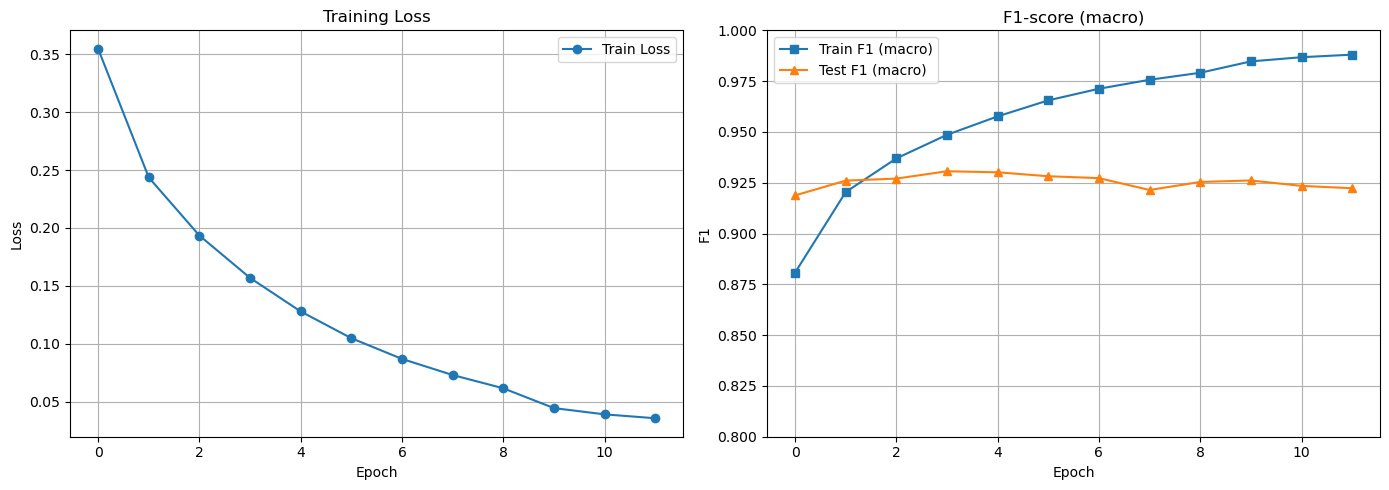

In [11]:
# %% [markdown]
# ## Визуализация обучения

# %%
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_f1s, label='Train F1 (macro)', marker='s')
plt.plot(val_f1s, label='Test F1 (macro)', marker='^')
plt.title('F1-score (macro)')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.ylim(0.8, 1.0)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

✅ Финальный macro F1 на test: 0.9285 (92.85%)

              precision    recall  f1-score   support

       World     0.9360    0.9242    0.9301      1900
      Sports     0.9694    0.9826    0.9760      1900
    Business     0.9021    0.8921    0.8971      1900
    Sci/Tech     0.9062    0.9153    0.9107      1900

    accuracy                         0.9286      7600
   macro avg     0.9284    0.9286    0.9285      7600
weighted avg     0.9284    0.9286    0.9285      7600



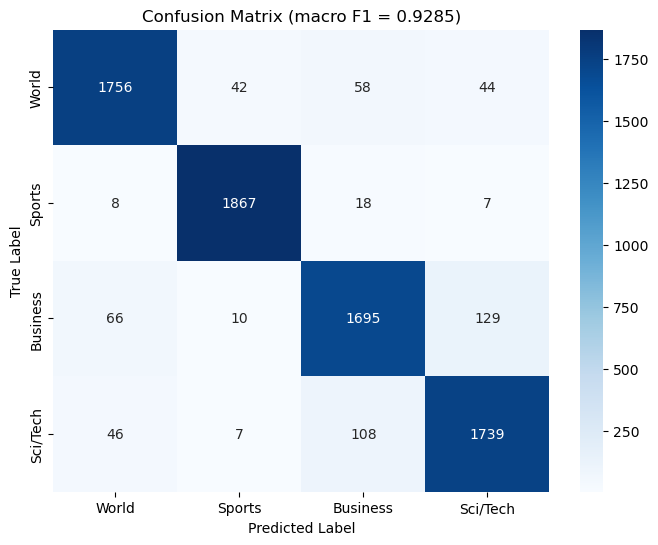

In [12]:
# %% [markdown]
# ## Финальная оценка на тесте

# %%
# 🔹 ДОБАВЬТЕ эту строку (или вставьте в начало ноутбука):
labels_map = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        texts, labels = batch
        texts, labels = texts.to(device), labels.to(device)
        logits = model(texts)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_f1 = f1_score(all_labels, all_preds, average='macro')
print(f"✅ Финальный macro F1 на test: {final_f1:.4f} ({final_f1*100:.2f}%)")
print("\n" + "="*50)
print(classification_report(all_labels, all_preds, 
                          target_names=list(labels_map.values()), 
                          digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(labels_map.values()),
            yticklabels=list(labels_map.values()))
plt.title(f'Confusion Matrix (macro F1 = {final_f1:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()